
# Detailed Blockchain Lab Notebook with Visualizations
This notebook provides:
- Clear explanations for each concept
- A full blockchain implementation
- Proof-of-Work, difficulty, transactions, mining rewards
- Mining time visualization
---


**Note:
A real blockchain is a distributed system with multiple nodes, networks, consensus rules, and security mechanisms.
This notebook provides only a simplified, single‑node demonstration for learning purposes.**

##  Imports

In [14]:
pip install cryptography #To import Fenet (AES)

In [15]:
import hashlib  # for SHA‑256 hashing
import json     # for JSON encoding
import time     # for timestamps and timing
import random   # for random test values
import matplotlib.pyplot as plt  # for plotting charts
from typing import List, Dict, Any  # for type hints
from cryptography.fernet import Fernet # For AES encryption

**Block Class**

A block contains transactions and must be mined by finding a valid hash starting with a number of leading zeros determined by the difficulty.

In [16]:

class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty):
        self.index = index              # block number
        self.timestamp = timestamp      # time created
        self.transactions = transactions # list of txs
        self.previous_hash = previous_hash  # hash of previous block
        self.difficulty = difficulty    # mining difficulty
        self.nonce = 0                  # PoW counter
        self.hash = None                # final block hash

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()  # compute hash

    def mine(self):
        target = '0' * self.difficulty  # target prefix
        start = time.time()             # start time
        attempts = 0                    # count tries
        while True:
            self.hash = self.compute_hash()  # calculate hash
            if self.hash.startswith(target):  # valid PoW?
                break
            self.nonce += 1                  # try next nonce
            attempts += 1
        return time.time() - start, attempts  # mining duration + attempts


##  Blockchain Class

The blockchain links blocks together and manages transactions, mining, verification, and exporting.

In [17]:

class Blockchain:
    def __init__(self, difficulty=3, reward=10):
        self.chain = []                # list of blocks
        self.difficulty = difficulty   # mining difficulty
        self.reward = reward           # block reward
        self.pending = []              # pending transactions
        self.create_genesis()          # create first block

    def create_genesis(self):
        b = Block(
            0,
            time.time(),
            [{"sender": "network", "recipient": "genesis", "amount": 0}],
            "0",
            self.difficulty
        )
        b.mine()                       # mine genesis block
        self.chain.append(b)           # add to chain

    def add_transaction(self, sender, recipient, amount):
        self.pending.append({
            "sender": sender,
            "recipient": recipient,
            "amount": amount
        })                             # store pending tx

    def mine_pending(self, miner):
        reward_tx = {"sender": "network", "recipient": miner, "amount": self.reward}
        txs = [reward_tx] + self.pending            # include reward + pending txs
        prev = self.chain[-1]                       # last block
        b = Block(len(self.chain), time.time(), txs, prev.hash, self.difficulty)
        t, attempts = b.mine()                      # mine new block
        self.chain.append(b)                        # add block to chain
        self.pending = []                           # clear mempool
        return t, attempts                          # return mining stats

    def export_json(self, filename):
        data = [b.__dict__ for b in self.chain]     # serialize blocks
        s = json.dumps(data, indent=2)              # format JSON
        open(filename, 'w').write(s)                # write file
        return s                                    # return JSON string


## 🚀 Example: Create Blockchain and Add Transactions

In [18]:

bc = Blockchain(difficulty=5, reward=25)   # create blockchain

# Add transactions
bc.add_transaction("Alice", "Bob", 10)      # Alice → Bob
bc.add_transaction("Bob", "Charlie", 5)     # Bob → Charlie
bc.add_transaction("Charlie", "Dave", 2)    # Charlie → Dave

time_taken, attempts = bc.mine_pending("Miner1")  # mine block + reward
print("Mining time:", time_taken, "seconds")       # show mining time
print("Attempts:", attempts)                       # show attempts made

Mining time: 58.48663830757141 seconds
Attempts: 3755435


In [19]:
for b in bc.chain:
    print(f"Block #{b.index}")
    print(f" Timestamp   : {b.timestamp}")
    print(f" Hash        : {b.hash}")
    print(f" Prev Hash   : {b.previous_hash}")
    print(f" Difficulty  : {b.difficulty}")
    print(f" Nonce       : {b.nonce}")
    print(f" Transactions: {b.transactions}")
    print("-" * 50)

Block #0
 Timestamp   : 1773675353.8228416
 Hash        : 00000219a8182d9af391fb6fa96c7435166977ec9d5e75127186ee82424c228b
 Prev Hash   : 0
 Difficulty  : 5
 Nonce       : 413678
 Transactions: [{'sender': 'network', 'recipient': 'genesis', 'amount': 0}]
--------------------------------------------------
Block #1
 Timestamp   : 1773675358.2614052
 Hash        : 000007c52119b0b221070d0cf98533b5ebd44d28168a686729af03f3fd5f08ae
 Prev Hash   : 00000219a8182d9af391fb6fa96c7435166977ec9d5e75127186ee82424c228b
 Difficulty  : 5
 Nonce       : 3755435
 Transactions: [{'sender': 'network', 'recipient': 'Miner1', 'amount': 25}, {'sender': 'Alice', 'recipient': 'Bob', 'amount': 10}, {'sender': 'Bob', 'recipient': 'Charlie', 'amount': 5}, {'sender': 'Charlie', 'recipient': 'Dave', 'amount': 2}]
--------------------------------------------------


## Mining Time Visualization

We test multiple difficulty levels and plot the mining times to show how difficulty impacts mining cost.

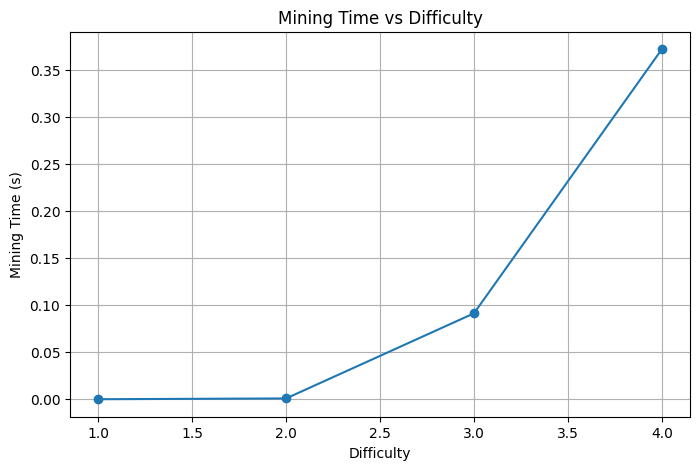

In [20]:

difficulties = [1, 2, 3, 4]        # test difficulty levels
times = []                         # store mining times

for d in difficulties:
    bc = Blockchain(difficulty=d, reward=1)  # new chain per difficulty
    bc.add_transaction("A", "B", 1)          # simple tx
    t, att = bc.mine_pending("MinerX")       # mine and time
    times.append(t)                           # record time

plt.figure(figsize=(8, 5))                   # set figure size
plt.plot(difficulties, times, marker='o')    # line plot with markers
plt.xlabel('Difficulty')                     # x-axis label
plt.ylabel('Mining Time (s)')                # y-axis label
plt.title('Mining Time vs Difficulty')       # chart title
plt.grid(True)                               # show grid
plt.show()                                   # render plot


#  Student Challenges
1. Note that your data is not encrypted inside the blocks, so anyone can read it. Encrypt the data before storing it in each block. Use encryption methods such as AES or 3DES.

2. Modify the mining function so it no longer uses leading‑zero matching; instead apply a different Proof‑of‑Work rule, such as a numeric hash threshold, pattern matching, or a time‑limited mining attempt.

Some options can be:

* Numeric threshold: Convert the hash to an integer and check if it's below a target value.
* Pattern rule: Make the hash end with certain characters (e.g., "00"), or require a substring inside the hash.
* Time‑limited PoW: Stop mining after a fixed time or attempt limit and mark the block as failed.
* Difficulty idea: Control difficulty by adjusting pattern length or the numeric target size.


# LAB-LOGBOOK requirement:
Show a graph comparing the mining time of the different Proof‑of‑Work methods used in Challenge 2.









Running comparison (Difficulty Level: 16)...


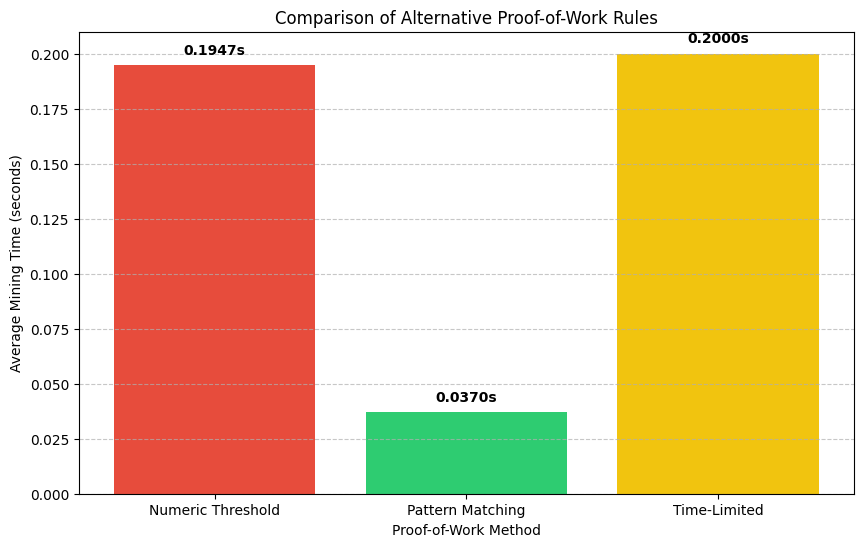

In [26]:
import hashlib
import json
import time
import matplotlib.pyplot as plt
from cryptography.fernet import Fernet

class Block:
    def __init__(self, index, timestamp, transactions, previous_hash, difficulty, encryption_key):
        self.index = index
        self.timestamp = timestamp
        self.previous_hash = previous_hash
        self.difficulty = difficulty
        self.nonce = 0
        self.encryption_key = encryption_key

        # Challenge 1: AES Encryption - Fernet
        self.cipher_suite = Fernet(encryption_key)
        self.encrypted_transactions = self.encrypt_data(transactions)
        self.hash = None

    def encrypt_data(self, data):
        json_data = json.dumps(data).encode()
        return self.cipher_suite.encrypt(json_data).decode()

    def compute_hash(self):
        data = {
            "index": self.index,
            "timestamp": self.timestamp,
            "transactions": self.encrypted_transactions,
            "previous_hash": self.previous_hash,
            "difficulty": self.difficulty,
            "nonce": self.nonce
        }
        return hashlib.sha256(json.dumps(data, sort_keys=True).encode()).hexdigest()

    # Challenge 2: New Mining Rules
    def mine_numeric(self):
        # Numeric Threshold Mining Function
        target = 2**(256 - self.difficulty)
        start = time.time()
        while True:
            self.hash = self.compute_hash()
            if int(self.hash, 16) < target:
                break
            self.nonce += 1
        return time.time() - start

    def mine_pattern(self, pattern="000"):
        #Pattern Matching Mining Function
        start = time.time()
        while True:
            self.hash = self.compute_hash()
            if self.hash.endswith(pattern):
                break
            self.nonce += 1
        return time.time() - start

    def mine_time_limited(self, limit=0.2):
        #Time-limited Attempt Mining Function
        target = 2**(256 - (self.difficulty + 2)) # Higher difficulty for testing
        start = time.time()
        while (time.time() - start) < limit:
            self.hash = self.compute_hash()
            if int(self.hash, 16) < target:
                return time.time() - start # Success
            self.nonce += 1
        return limit # Failed: Max time reached

# --- Comparison and Plotting Logic ---

def run_pow_comparison(difficulty=16, trials=5):
    methods = {
        "Numeric Threshold": [],
        "Pattern Matching": [],
        "Time-Limited": []
    }

    key = Fernet.generate_key()
    txs = [{"sender": "Alice", "recipient": "Bob", "amount": 50}]

    print(f"Running comparison (Difficulty Level: {difficulty})...")

    for _ in range(trials):
        # 1. Test Numeric
        b_num = Block(1, time.time(), txs, "0", difficulty, key)
        methods["Numeric Threshold"].append(b_num.mine_numeric())

        # 2. Test Pattern
        b_pat = Block(1, time.time(), txs, "0", difficulty, key)
        methods["Pattern Matching"].append(b_pat.mine_pattern(pattern="000"))

        # 3. Test Time-Limited
        b_time = Block(1, time.time(), txs, "0", difficulty, key)
        methods["Time-Limited"].append(b_time.mine_time_limited(limit=0.2))

    # Calculate average mining times
    avg_times = {name: sum(times)/len(times) for name, times in methods.items()}
    return avg_times

# Run the benchmark
avg_results = run_pow_comparison()

# Generate the Bar Chart
plt.figure(figsize=(10, 6))
colors = ['#e74c3c', '#2ecc71', '#f1c40f']
plt.bar(avg_results.keys(), avg_results.values(), color=colors)

plt.xlabel('Proof-of-Work Method')
plt.ylabel('Average Mining Time (seconds)')
plt.title('Comparison of Alternative Proof-of-Work Rules')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels
for i, v in enumerate(avg_results.values()):
    plt.text(i, v + 0.005, f"{v:.4f}s", ha='center', fontweight='bold')

plt.show()